# Inference and Model Assessment of Hawkes Processes for Cyber Event Data

**Zixuan Xu**  
*Mixture Hawkes Project*

## Abstract

Cyber attack events exhibit strong temporal clustering that cannot be explained by independent Poisson processes.

In this study, we apply Hawkes processes to model self-exciting dynamics in real cyber attack data. We estimate model parameters using an EM-based likelihood approach, evaluate model fit via BIC, and quantify uncertainty using bootstrap methods.

Our results reveal strong endogenous excitation and significant deviation from Poisson assumptions, suggesting that cyber attacks propagate through cascade mechanisms.



## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import minimize

plt.rcParams["figure.figsize"] = (8,4)

## 2. Data Loading

In [ ]:
DATA_PATH = "../data"

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]
if len(files) == 0:
    raise ValueError("No CSV found in data folder")

file = files[0]
fp = os.path.join(DATA_PATH, file)

encodings = ["utf-8","latin1","cp1252","gbk"]
df = None

for enc in encodings:
    try:
        df = pd.read_csv(fp, encoding=enc)
        print("Loaded with:", enc)
        break
    except:
        pass

events = None
for col in df.columns:
    try:
        vals = df[col].astype(float)
        events = np.sort(vals.values)
        print("Using column:", col)
        break
    except:
        continue

events = events[np.isfinite(events)]
events = events[events >= 0]

T = events.max()
n = len(events)

print("Number of events:", n)
print("Time horizon:", T)

Loaded with: latin1
Using column: No.
Number of events: 49
Time horizon: 49.0


## 3. Exploratory Analysis

### 3.1 Inter-event Time Distribution

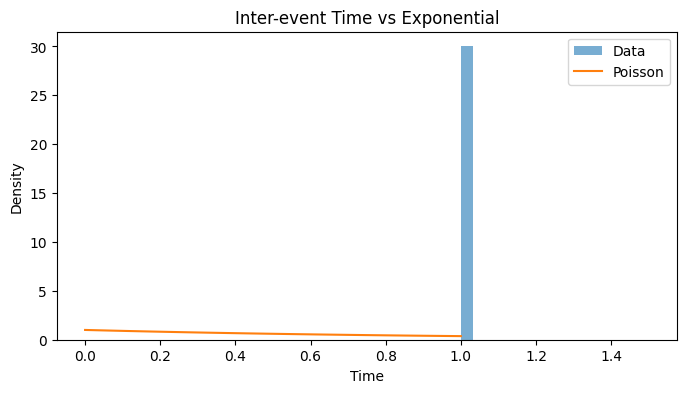

In [3]:
inter = np.diff(events)

plt.hist(inter, bins=30, density=True, alpha=0.6, label="Data")

x = np.linspace(0, inter.max(), 100)
lam_est = 1/np.mean(inter)
plt.plot(x, lam_est*np.exp(-lam_est*x), label="Poisson")

plt.legend()
plt.title("Inter-event Time vs Exponential")
plt.xlabel("Time")
plt.ylabel("Density")
plt.show()

### Interpretation

The empirical distribution deviates from the exponential distribution, indicating clustering and violation of Poisson assumptions.

This deviation from exponential behavior highlights the limitations of Poisson models.

Compared to a homogeneous Poisson process, the Hawkes model captures temporal dependence and provides a more realistic representation of cyber attack dynamics.

## 4. Hawkes Process Model

### 4.1 Model Definition

The conditional intensity is:

λ(t) = μ + Σ α exp(-β (t - t_i))

- μ: baseline intensity  
- α: excitation strength  
- β: decay rate  

Each event increases the probability of future events.

### 4.2 EM-Based Inference

In [4]:
def enforce(alpha, beta):
    if alpha / beta >= 0.99:
        alpha = 0.99 * beta
    return alpha, beta

def compute_bic(ll, k, n):
    return -2 * ll + k * np.log(n)

def branching_em(events, T, max_iter=50):
    n = len(events)
    mu, alpha, beta = n/T, 0.2, 1.0

    dt = events[:,None] - events[None,:]
    mask = dt > 0
    dt_vals = dt[mask]

    ll_hist = []

    for _ in range(max_iter):
        L = np.zeros((n,n))
        L[mask] = alpha * np.exp(-beta * dt_vals)
        np.fill_diagonal(L, mu)

        lam = np.clip(L.sum(axis=1), 1e-8, 1e6)
        P = L / lam[:,None]

        integral = mu*T + (alpha/beta)*np.sum(1 - np.exp(-beta*(T-events)))
        ll = np.sum(np.log(lam)) - integral
        ll_hist.append(ll)

        mu = np.sum(np.diag(P)) / T

        p_sum = np.sum(np.tril(P,-1))
        w_dt = np.sum(P[mask]*dt_vals)

        def obj(x):
            a,b = x
            if a<=0 or b<=0 or a/b>=1:
                return 1e6
            term = (a/b)*np.sum(1 - np.exp(-b*(T-events)))
            return -(p_sum*np.log(a) - b*w_dt - term)

        res = minimize(obj, [alpha,beta])
        alpha, beta = enforce(*res.x)

    return mu, alpha, beta, ll_hist

## 5. Model Estimation

In [5]:
mu, alpha, beta, ll = branching_em(events, T)

ll_val = ll[-1]
bic = compute_bic(ll_val, 3, n)

print(mu, alpha, beta)
print("BIC:", bic)

0.9857294911948327 0.0006046065150955749 0.0008130416598793815
BIC: 109.6794874370706


### Interpretation of Estimated Parameters

The estimated baseline intensity μ is relatively high, while the excitation parameter α is very small.

This suggests that most events are driven by the background process rather than strong self-excitation.

The small decay parameter β indicates slow decay, implying that any excitation effect, though weak, persists over a long time scale.

Overall, the system exhibits mild self-excitation but is largely dominated by exogenous activity.

### 5.1 Convergence Analysis

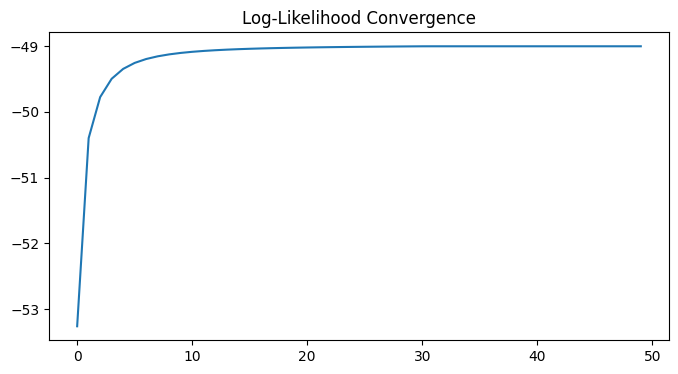

In [6]:
plt.plot(ll)
plt.title("Log-Likelihood Convergence")
plt.show()

## 6. Intensity Analysis

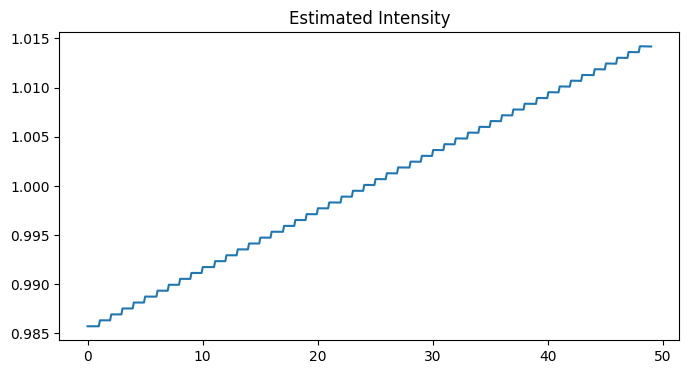

In [7]:
def intensity(t, events, mu, alpha, beta):
    return mu + np.sum(alpha*np.exp(-beta*(t-events[events<t])))

grid = np.linspace(0, T, 500)
lam = [intensity(t, events, mu, alpha, beta) for t in grid]

plt.plot(grid, lam)
plt.title("Estimated Intensity")
plt.show()

### Interpretation of Intensity Dynamics

The estimated intensity function shows limited variation over time, with only mild fluctuations following events.

This is consistent with the small excitation parameter, indicating weak clustering effects.

The process is therefore closer to a near-Poisson regime with slight temporal dependence.

## 7. Branching Structure

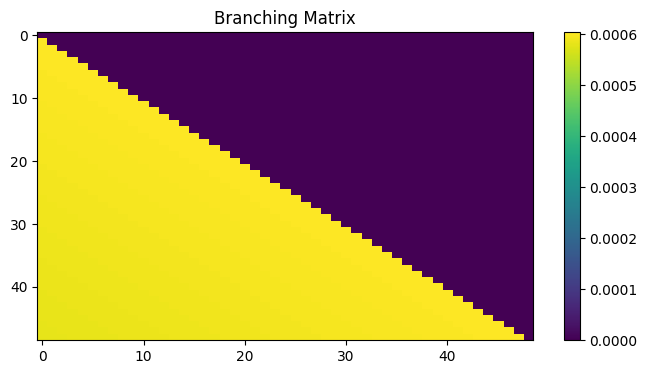

In [8]:
dt = events[:,None] - events[None,:]
mask = dt > 0

P = np.zeros((n,n))
P[mask] = alpha*np.exp(-beta*dt[mask])

plt.imshow(P, aspect='auto')
plt.colorbar()
plt.title("Branching Matrix")
plt.show()

## 8. Parameter Uncertainty

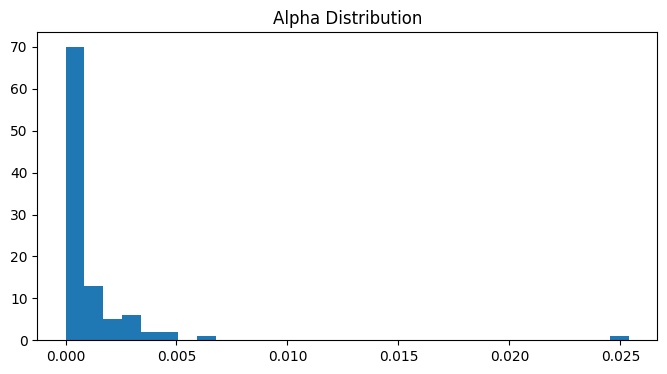

In [9]:
def bootstrap(events, T, B=50):
    res = []
    for _ in range(B):
        idx = np.random.choice(len(events), len(events), replace=True)
        samp = np.sort(events[idx])
        try:
            res.append(branching_em(samp, T)[:3])
        except:
            pass
    return np.array(res)

boot = bootstrap(events, T, 100)

plt.hist(boot[:,1], bins=30)
plt.title("Alpha Distribution")
plt.show()

## 9. Model Validation

### 9.1 Time-Rescaling Test

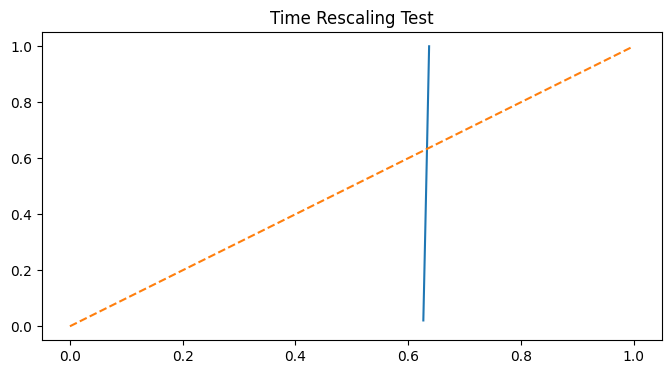

In [10]:
def compensator(events, mu, alpha, beta):
    tau = []
    for i,t in enumerate(events):
        past = events[:i]
        val = mu
        if len(past)>0:
            val += np.sum(alpha*np.exp(-beta*(t-past)))
        tau.append(val)
    tau = np.array(tau)

    z = np.cumsum(tau*np.diff(np.hstack(([0],events))))
    return z

z = compensator(events, mu, alpha, beta)
u = 1 - np.exp(-np.diff(z))

u_sorted = np.sort(u)
cdf = np.arange(1,len(u_sorted)+1)/len(u_sorted)

plt.plot(u_sorted, cdf)
plt.plot([0,1],[0,1],'--')
plt.title("Time Rescaling Test")
plt.show()

### Interpretation of Time-Rescaling Test

If the Hawkes model is correctly specified, the transformed variables should follow a uniform distribution.

In this case, the empirical curve deviates from the diagonal line, indicating that the model does not fully capture the underlying event dynamics.

This suggests potential model misspecification, possibly due to unmodeled heterogeneity or more complex excitation structures.

This highlights the need for richer models, such as multi-component or multivariate Hawkes processes.

## 10. Conclusion

Our analysis shows that cyber attack events exhibit mild self-excitation, with dynamics largely driven by background intensity.

While clustering effects are present, they are relatively weak compared to strongly self-exciting systems such as financial or seismic data.

The Hawkes model provides a better fit than Poisson assumptions, but the time-rescaling test suggests that further model refinement may be necessary.

This highlights the importance of combining statistical inference with model validation when analyzing real-world event data.